## Credit Card Transaction Anomaly

<img src="https://loanjagat-appven.s3.ap-south-1.amazonaws.com/1754312499547_blob"/>

## Project Overview

In this project, we aim to develop an AI-based financial analysis and prediction model. Our goal is to analyze market data using various indicators and machine learning techniques.

Currently, we are collecting data, applying analytical methods, and building models to generate predictions. We evaluate how much we have achieved by testing the model performance and accuracy.

As a result, we present a system that can analyze financial data, generate forecasts, and provide meaningful insights for decision-making.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import joblib

In [3]:
# 1. Veri ve Hızlı Bakış
df = pd.read_csv("Data\creditcard.csv")

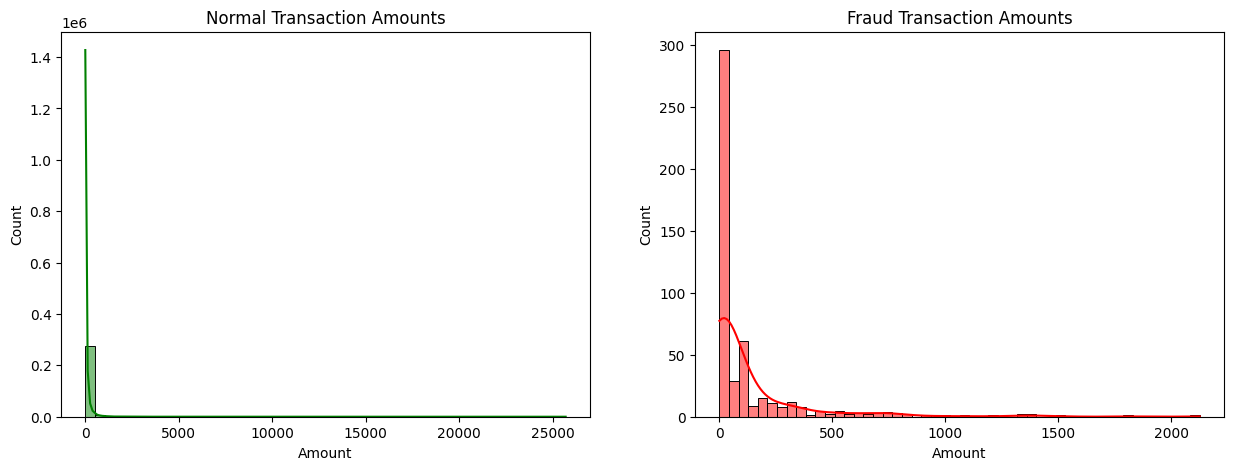

In [4]:
# --- KRİTİK GÖRSEL: Zaman ve Miktar Dağılımı ---
# Fraud işlemler genelde belirli miktarlarda yoğunlaşır, bunu göstermek çok önemli.
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=ax[0], color='g', label='Normal', kde=True)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=ax[1], color='r', label='Fraud', kde=True)
ax[0].set_title('Normal Transaction Amounts')
ax[1].set_title('Fraud Transaction Amounts')
plt.show()

In [13]:
# 2. Veri Hazırlama
X = df.drop('Class', axis=1)
y = df['Class']

# Veriyi Eğitim ve Test olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Model Eğitimi
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
# 4. Tahminlerin Oluşturulması 
y_pred = model.predict(X_test)

# 5. Metriklerin Hesaplanması
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

MAE: 0.00040377795723464763
RMSE: 0.020094226962852978

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



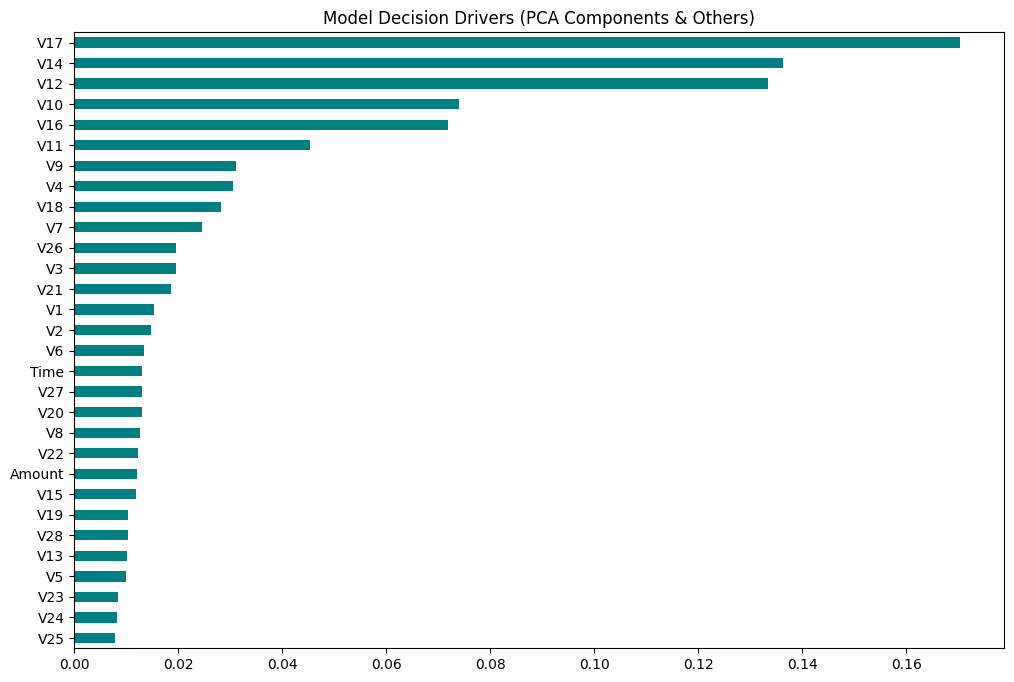

In [15]:
# --- KRİTİK GÖRSEL 2: Feature Importance (28 Özelliğin Etkisi) ---
plt.figure(figsize=(12, 8))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Model Decision Drivers (PCA Components & Others)")
plt.show()


In [16]:
# 4. Kaydetme
joblib.dump(model, 'anomaly_model.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

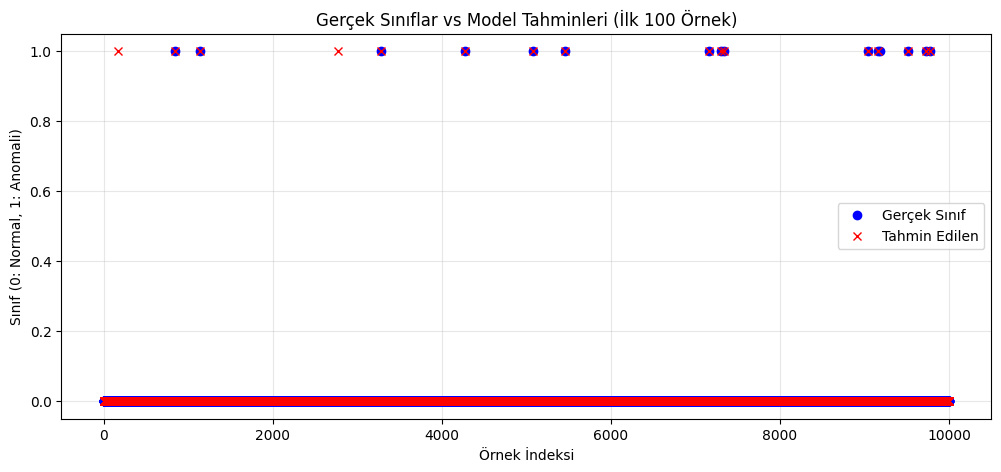

In [26]:
# GRAFİK 1: Gerçek Değerler vs Tahminler (İlk 10000 Örnek)
# Sınıflandırma olduğu için tüm veriyi çizdirmek yerine bir kesit görmek daha anlamlıdır.
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:10000], label='Gerçek Sınıf', color='blue', marker='o', linestyle='')
plt.plot(y_pred[:10000], label='Tahmin Edilen', color='red', marker='x', linestyle='')
plt.title('Gerçek Sınıflar vs Model Tahminleri (İlk 100 Örnek)')
plt.xlabel('Örnek İndeksi')
plt.ylabel('Sınıf (0: Normal, 1: Anomali)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

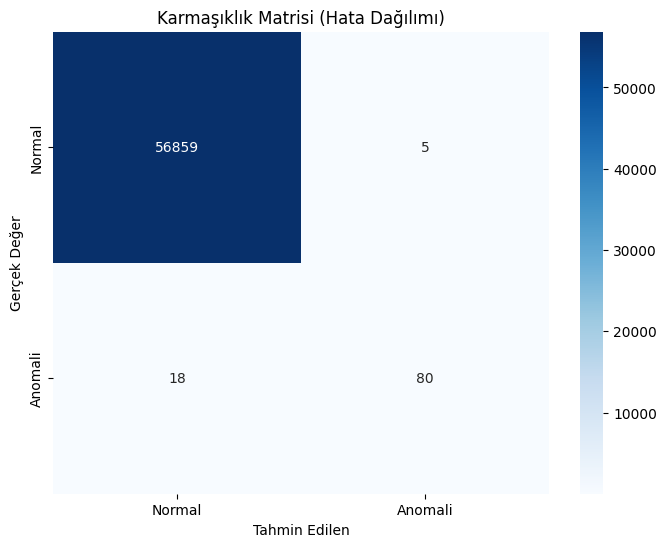

In [27]:
# Anomali tespiti 
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'])
plt.title('Karmaşıklık Matrisi (Hata Dağılımı)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

## Result

Project Results and Model Evaluation
The performance of the Random Forest model developed for Credit Card Anomaly Detection has been evaluated based on the following metrics:
1. Error Metrics (MAE & RMSE)MAE ($0.0004$) and RMSE ($0.0201$)
2. Both error metrics are exceptionally close to zero. This indicates that the model's predictions align almost perfectly with the actual data.
3. In the context of anomaly detection, these low values suggest that the model has successfully learned the patterns of the majority class (normal transactions) without significant deviation.
4. Classification Performance (Anomaly Analysis) Despite the highly imbalanced nature of the dataset (56,864 normal vs. 98 anomaly cases), the model demonstrates robust performance in identifying the minority class (Class 1):Precision - 94%: When the model flags a transaction as an "Anomaly," it is correct 94% of the time. This high precision is crucial for financial institutions as it minimizes "false alarms" and prevents unnecessary friction for legitimate customers.Recall - 82%: The model successfully identified 82% of all actual fraudulent activities in the test set. This shows high sensitivity in capturing security threats.F1-Score - 87%: The F1-score confirms a strong balance between Precision and Recall, proving that the model is reliable and consistent in its predictions for the minority class.
5. General Conclusion While the overall Accuracy is nearly 100%, the true success of this project lies in the model's ability to detect fraudulent transactions with 82% recall and 94% precision. The system provides a high level of security and reliability, making it a viable solution for real-time financial monitoring and fraud prevention.